## Setup

In [10]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from utils.general_utils import PROJECT_ROOT, SELECTION_CUTS, target_config
from utils.evaluation_utils import cut_table


def load(path):
    if not path.exists():
        raise SystemExit(f"missing: {path}\n"
                         "Has train_classifier.py been run for this "
                         "model/target/feature set?")
    with open(path, "rb") as f:
        return pickle.load(f)


TARGET     = "pion"            # "pion" | "photon"
COMPARISON = "features"    # "architecture" | "features"
cfg = target_config(TARGET)

PRED_DIR  = PROJECT_ROOT / "predictions" / "predictions-mc"
PLOTS_DIR = PROJECT_ROOT / "plots" / "model-comparison" / TARGET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Explicit filenames rather than the promoted unsuffixed ones, so this notebook
# records exactly which models it compared.
if COMPARISON == "architecture":
    SPEC = [
        ("CNN",    f"cnn_dEdX_seq{cfg['suffix']}.pkl",         'steelblue'),
        ("MLP",    f"mlp_summary_base4{cfg['suffix']}.pkl",    'darkorange'),
        ("Hybrid", f"hybrid_cnn_mlp_base4{cfg['suffix']}.pkl", 'crimson'),
    ]
    SUBTITLE = "identical inputs: the four original summary features"
else:
    SPEC = [
        ("Hybrid base4", f"hybrid_cnn_mlp_base4{cfg['suffix']}.pkl", 'grey'),
        ("Hybrid all8",  f"hybrid_cnn_mlp_all8{cfg['suffix']}.pkl",  'crimson'),
    ]
    SUBTITLE = "same architecture, with and without the provenance features"

MODELS = {name: load(PRED_DIR / fn) for name, fn, _ in SPEC}
COLOURS = {name: c for name, _, c in SPEC}

print(f"target: {TARGET} ({cfg['signal_name']})")
print(f"comparison: {COMPARISON} — {SUBTITLE}\n")
for name, fn, _ in SPEC:
    r = MODELS[name]
    print(f"{name:<15} {r['model_name']}")
    print(f"{'':<15} AUC {r['auc']:.3f}   purity {100*r['purity']:.1f}%   "
          f"efficiency {100*r['efficiency']:.1f}%   ({fn})")

target: pion ($\pi^{\pm}$)
comparison: features — same architecture, with and without the provenance features

Hybrid base4    hybrid base4 -- pion target
                AUC 0.895   purity 52.3%   efficiency 77.4%   (hybrid_cnn_mlp_base4_pion.pkl)
Hybrid all8     hybrid all8 -- pion target
                AUC 0.930   purity 62.9%   efficiency 78.1%   (hybrid_cnn_mlp_all8_pion.pkl)


## Cut-based baseline

In [11]:
TRACKS_PATH = PROJECT_ROOT / "prepared" / "prepared-mc" / "test_tracks.pkl"
with open(TRACKS_PATH, "rb") as f:
    test_pfos = pickle.load(f)

cut_rows = cut_table(test_pfos, SELECTION_CUTS[TARGET], cfg['is_signal'], label=TARGET)
final = cut_rows[-1]

TP, FP, FN, TN = final['TP'], final['FP'], final['FN'], final['TN']
tpr_cut  = TP / (TP + FN)
fpr_cut  = FP / (FP + TN)
pur_cut  = TP / (TP + FP)
dpur_cut = final['d_purity']

print(f"\nCut-based operating point:  FPR = {100*fpr_cut:.2f}%, "
      f"efficiency = {100*tpr_cut:.2f}%, purity = {100*pur_cut:.1f} ± {dpur_cut:.1f}%\n")

for name in MODELS:
    r = MODELS[name]
    fpr_m, tpr_m, _ = roc_curve(r['labels'], r['probs'])
    at_cut = np.interp(fpr_cut, fpr_m, tpr_m)
    print(f"  {name:<15} at the same FPR: efficiency = {100*at_cut:.2f}%  "
          f"({100*(at_cut - tpr_cut):+.2f} pp)")


  pion cuts
  Cut added                              Purity        Efficiency    Selected
  ------------------------------------------------------------------------------
  (no cuts)                    17.6 ± 0.1%    100.0 ± 0.0%     126,817
  chi²/ndof_p > 61.2           23.1 ± 0.1%    94.4 ± 0.2%      91,397
  track length > 27.1          30.1 ± 0.2%    64.8 ± 0.3%      48,181
  track score > 0.5            39.2 ± 0.3%    61.6 ± 0.3%      35,108
  1.6 < dEdX median < 2.8      41.3 ± 0.3%    53.8 ± 0.3%      29,127
  ------------------------------------------------------------------------------
  Purity × Efficiency = 41.3% × 53.8% = 22.20%

Cut-based operating point:  FPR = 16.37%, efficiency = 53.79%, purity = 41.3 ± 0.3%

  Hybrid base4    at the same FPR: efficiency = 79.37%  (+25.58 pp)
  Hybrid all8     at the same FPR: efficiency = 87.35%  (+33.56 pp)


## ROC

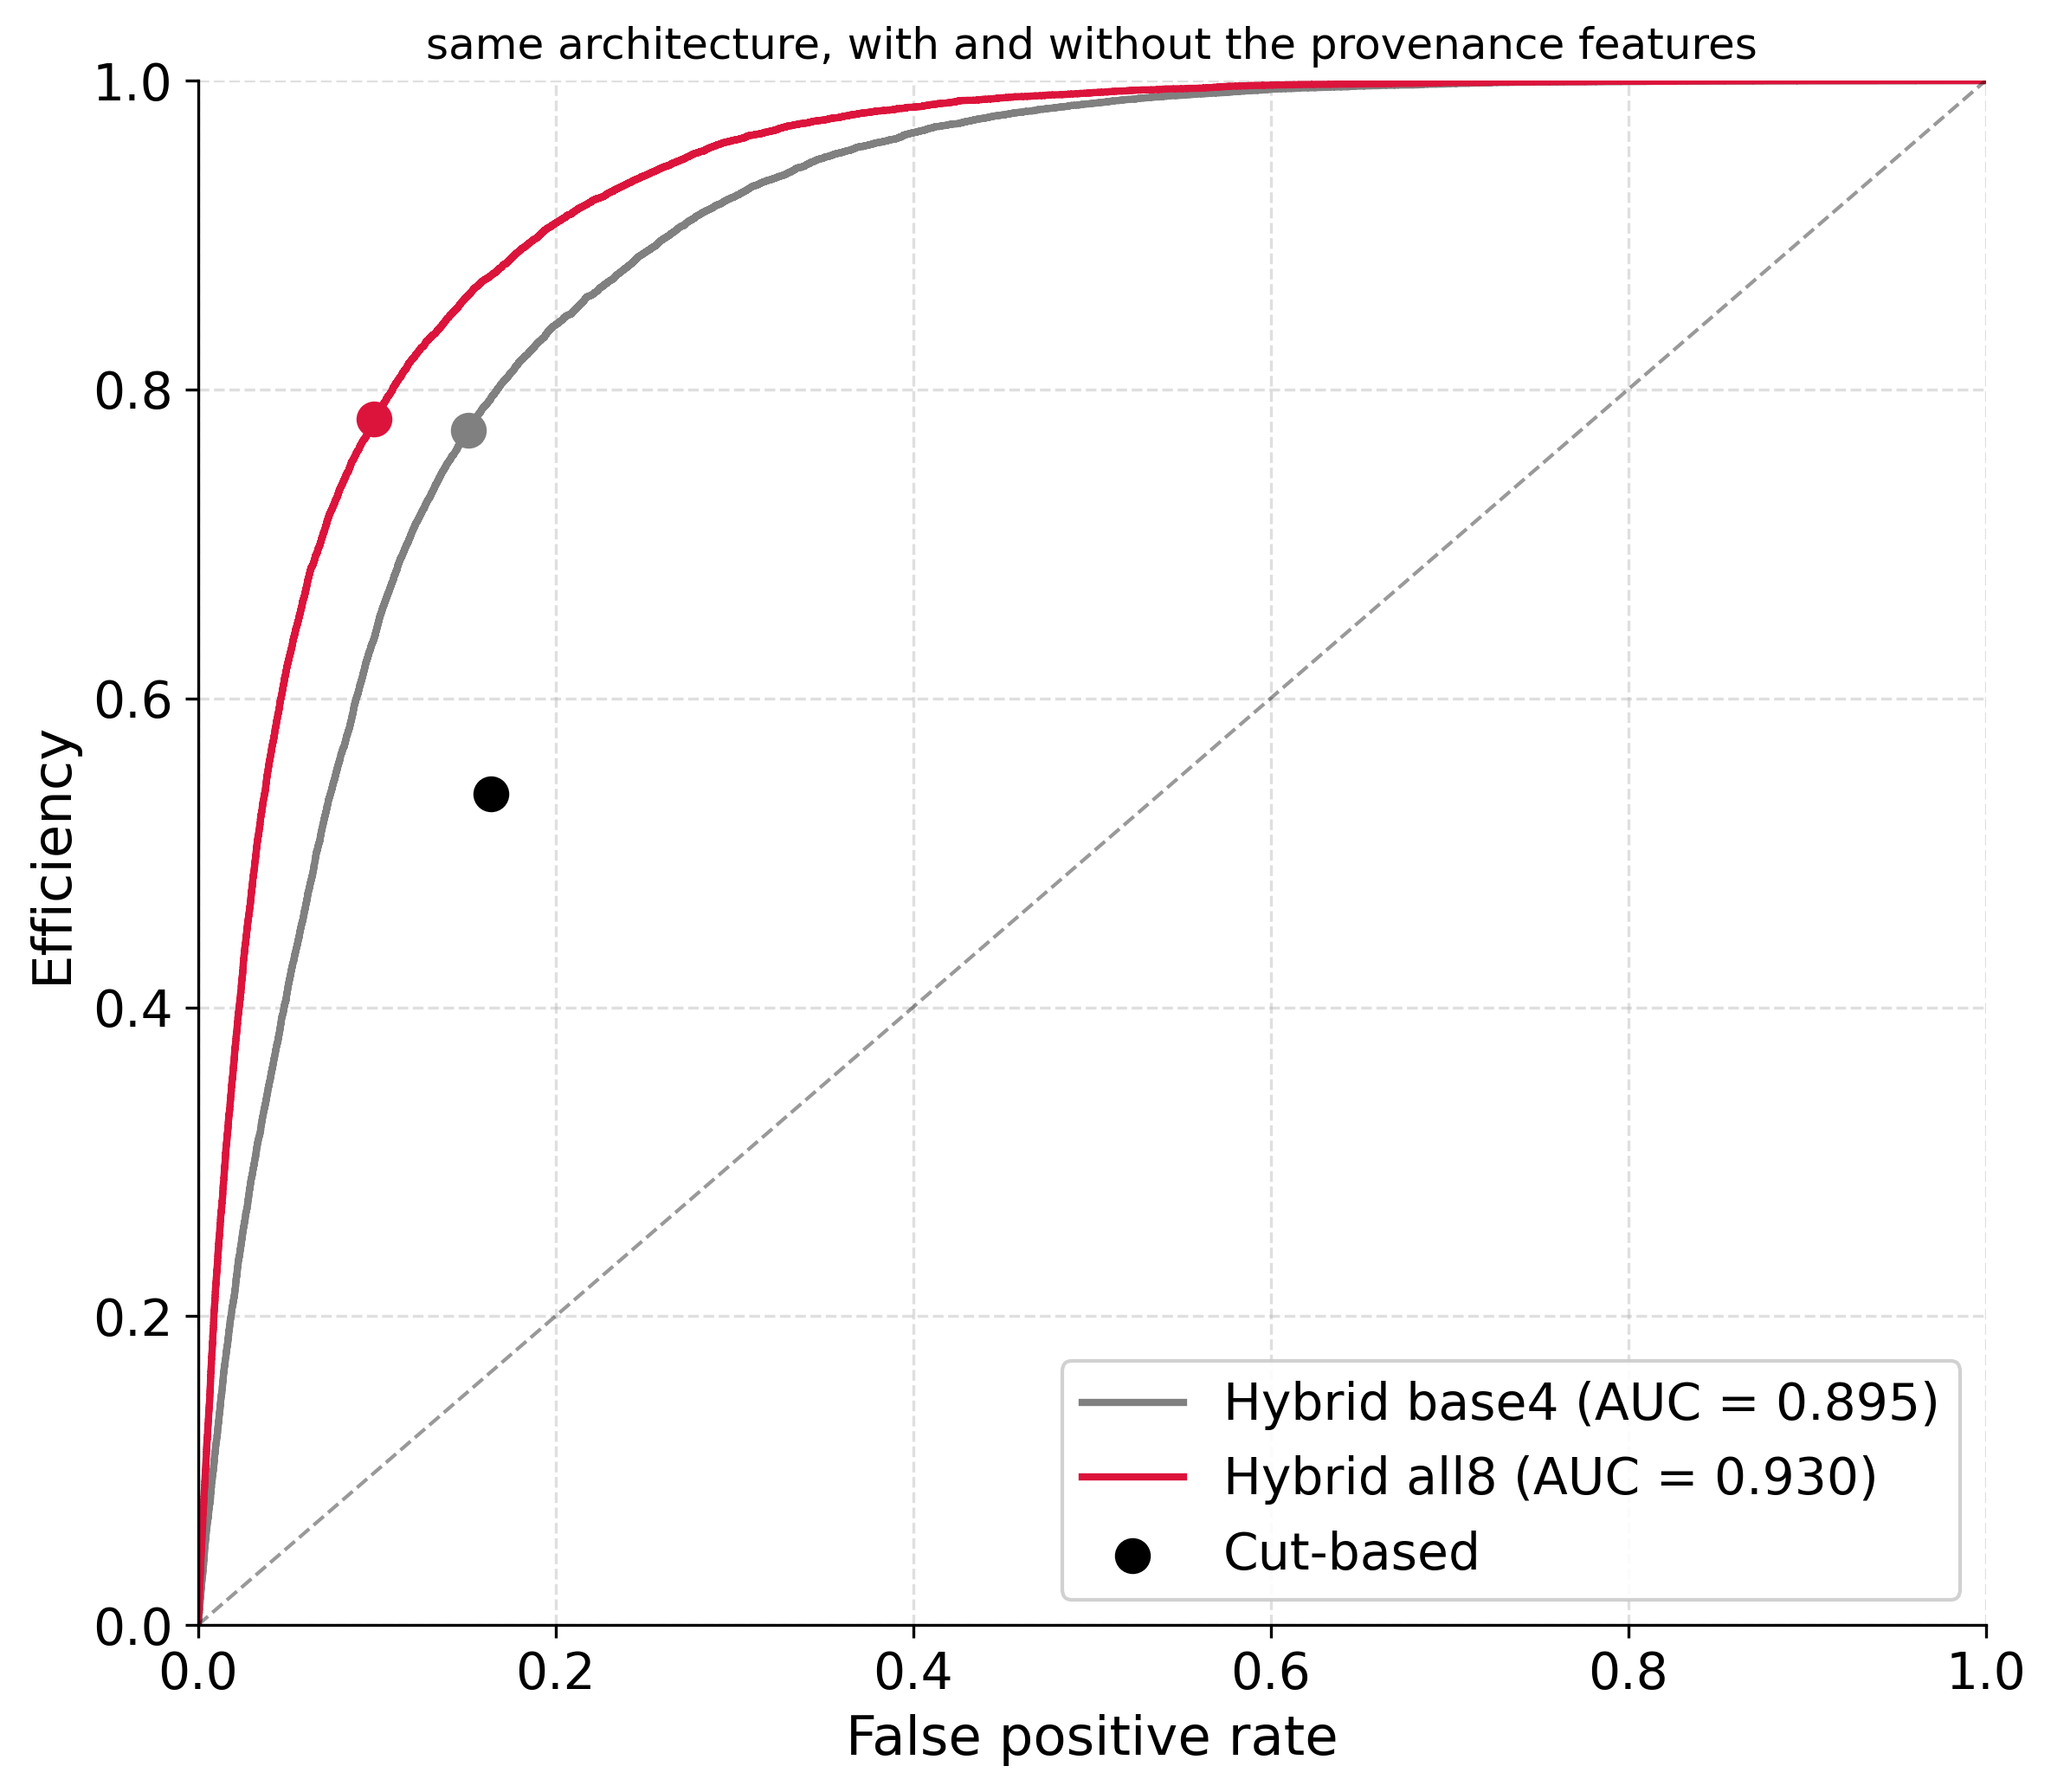

In [12]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

for name, _, color in SPEC:
    r = MODELS[name]
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

    preds = (r['probs'] >= r['threshold']).astype(int)
    tp = int(((preds == 1) & (r['labels'] == 1)).sum())
    fp = int(((preds == 1) & (r['labels'] == 0)).sum())
    fn = int(((preds == 0) & (r['labels'] == 1)).sum())
    tn = int(((preds == 0) & (r['labels'] == 0)).sum())
    ax.scatter(fp / (fp + tn), tp / (tp + fn), color=color, marker='o', s=80, zorder=5)

ax.scatter(fpr_cut, tpr_cut, color='black', marker='o', s=80, zorder=6,
           label='Cut-based')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1)
ax.set_xlabel('False positive rate', fontsize=15)
ax.set_ylabel('Efficiency', fontsize=15)
ax.set_title(SUBTITLE, fontsize=12)
ax.legend(fontsize=14, framealpha=0.9)
ax.tick_params(labelsize=14)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"roc_curve_{COMPARISON}_{TARGET}.pdf", bbox_inches="tight")
plt.show()

## Purity-at-matched-efficiency table

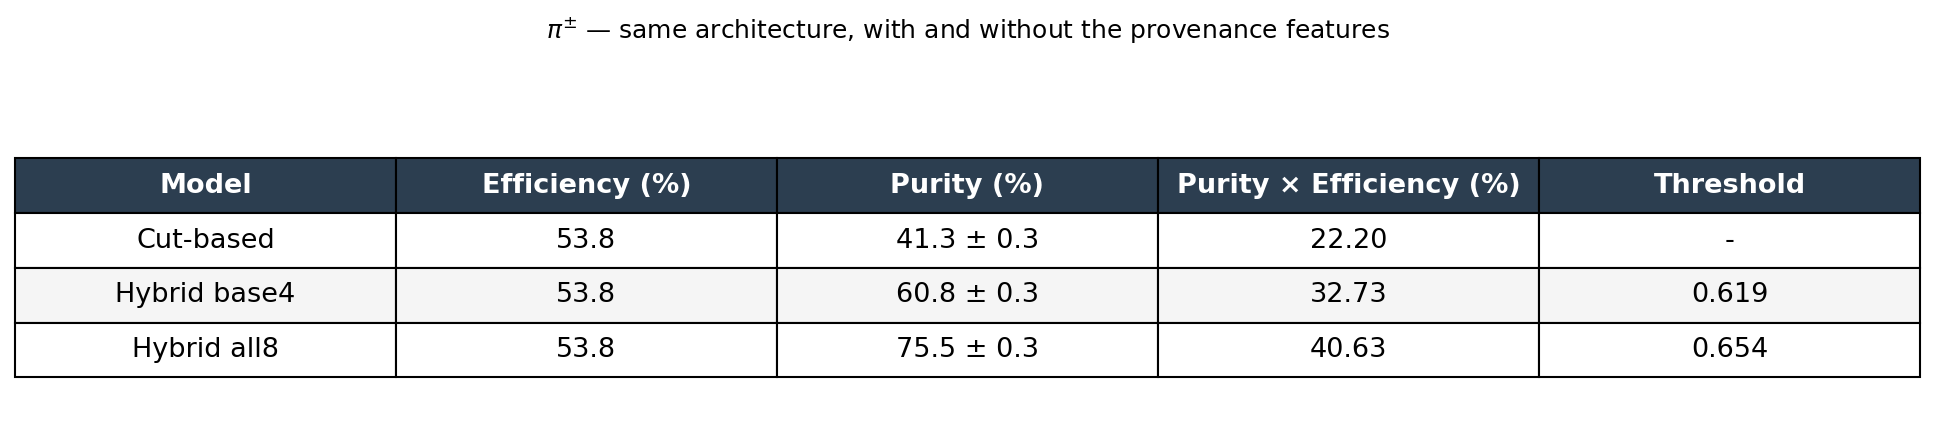


best at matched efficiency: Hybrid all8 at 75.5% purity, +34.3pp against the cuts


In [14]:
def thresh_at_eff(labels, probs, target, n=5000):
    """Threshold whose efficiency is closest to `target`."""
    best_t, best_d = 0.5, float('inf')
    for t in np.linspace(0.01, 0.99, n):
        preds = (probs >= t).astype(int)
        tp = int(((preds == 1) & (labels == 1)).sum())
        fn = int(((preds == 0) & (labels == 1)).sum())
        eff = tp / (tp + fn) if (tp + fn) else 0.0
        if abs(eff - target) < best_d:
            best_d, best_t = abs(eff - target), t
    return best_t


def purity_at(labels, probs, t):
    preds = (probs >= t).astype(int)
    tp = int(((preds == 1) & (labels == 1)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    if tp + fp == 0:
        return 0.0, 0.0
    p = tp / (tp + fp)
    return 100 * p, 100 * np.sqrt(p * (1 - p) / (tp + fp))


# Every model is tuned to the cut-based efficiency, so purity is compared at a
# common operating point. Without this a model could look better simply by
# sitting looser on its own ROC curve.
FIXED_EFF = 100 * tpr_cut

rows = [('Cut-based', 100 * pur_cut, dpur_cut, None)]
for name in MODELS:
    r = MODELS[name]
    t = thresh_at_eff(r['labels'], r['probs'], tpr_cut)
    pur, dpur = purity_at(r['labels'], r['probs'], t)
    rows.append((name, pur, dpur, t))

col_labels = ['Model', 'Efficiency (%)', 'Purity (%)',
              'Purity × Efficiency (%)', 'Threshold']
cell_text = [
    [name, f'{FIXED_EFF:.1f}', f'{pur:.1f} ± {dpur:.1f}',
     f'{pur * FIXED_EFF / 100:.2f}', f'{t:.3f}' if t is not None else '-']
    for name, pur, dpur, t in rows
]

fig, ax = plt.subplots(figsize=(13, 0.55 * (len(rows) + 1) + 0.6), dpi=150)
ax.axis('off')
tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1, 2.2)

for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(rows) + 1):
    bg = '#f5f5f5' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(bg)

plt.suptitle(f"{cfg['signal_name']} — {SUBTITLE}", fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"purity_table_{COMPARISON}_{TARGET}.pdf", bbox_inches="tight")
plt.show()

best = max(rows[1:], key=lambda r: r[1])
print(f"\nbest at matched efficiency: {best[0]} at {best[1]:.1f}% purity, "
      f"{best[1] - 100*pur_cut:+.1f}pp against the cuts")